# LSTM - Walk-Forward Validation

This notebook implements **LSTM (Long Short-Term Memory)** neural network for 24-hour ahead price forecasting.

## Why LSTM?

LSTM is a type of Recurrent Neural Network (RNN) designed for **sequential data**:
- ✅ **Temporal dependencies**: Learns patterns over time
- ✅ **Long-term memory**: Can remember patterns from hours/days ago
- ✅ **Non-linear**: Captures complex relationships
- ✅ **Feature interactions**: Learns combinations automatically

**When LSTM Helps:**
- Price patterns repeat over hours/days (hourly/daily cycles)
- Recent history matters (momentum, trends)
- Complex interactions between features

**Limitations:**
- ⚠️ **Slower training**: Hours instead of minutes
- ⚠️ **Needs more data**: Deep learning is data-hungry
- ⚠️ **Harder to tune**: Many hyperparameters
- ⚠️ **Less interpretable**: Black box

## Workflow
1. Load dataset (forecasts + lags only)
2. Create sequences (lookback window)
3. Build LSTM architecture
4. Walk-forward validation with daily retraining
5. Compare with tree-based models

In [7]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Add project root to path
project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

from model.price_forecasting.walk_forward_validator import calculate_price_forecast_metrics

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("✅ Imports successful")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

✅ Imports successful
TensorFlow version: 2.10.0
GPU available: []


## 1. Load Dataset (No Data Leakage)

In [8]:
# Load dataset
data_path = project_root / "data/processed/price_forecasting_dataset_with_forecasts.csv"

df = pd.read_csv(data_path)
df['datetime_hour'] = pd.to_datetime(df['datetime_hour'])

print(f"✅ Dataset loaded: {len(df):,} rows")
print(f"   Date range: {df['datetime_hour'].min()} to {df['datetime_hour'].max()}")
print(f"   Price range: [{df['price'].min():.2f}, {df['price'].max():.2f}] EUR/MWh")

# Load features
features_path = project_root / "data/processed/price_forecasting_dataset_with_forecasts_features.txt"
with open(features_path, 'r') as f:
    feature_cols = [line.strip() for line in f.readlines()]

print(f"\n✅ Features: {len(feature_cols)} (forecasts + lags ≥ 24h + calendar)")

df.head()

✅ Dataset loaded: 17,124 rows
   Date range: 2023-01-09 04:00:00 to 2024-12-30 23:00:00
   Price range: [-134.94, 284.21] EUR/MWh

✅ Features: 53 (forecasts + lags ≥ 24h + calendar)


,datetime_hour,price,load_actual,temp_actual,humidity_actual,precipitation_actual,wind10m_actual,wind100m_actual,solar_radiation_actual,cloudcover_actual,...,load_actual_lag_72h,load_actual_lag_168h,price_roll_mean_24h,price_roll_std_24h,price_roll_mean_168h,price_roll_std_168h,load_actual_roll_mean_24h,load_actual_roll_std_24h,load_actual_roll_mean_168h,load_actual_roll_std_168h
0,2023-01-09 04:00:00,43.99,48980.0,4.1,86,0.0,16.3,31.6,0.0,100,...,46641.0,39070.0,71.689583,33.348179,102.640238,51.681903,50336.583333,3253.258486,52106.875000,6152.152051
1,2023-01-09 05:00:00,85.26,54574.0,4.2,87,0.0,16.2,31.4,0.0,100,...,45825.0,38453.0,69.030000,35.587712,102.704107,51.560664,50333.750000,3258.789362,52097.952381,6162.564818
2,2023-01-09 06:00:00,160.32,60202.0,4.6,86,0.0,15.3,29.8,0.0,100,...,47788.0,40294.0,67.002500,37.170492,102.810060,51.363515,50328.083333,3268.771767,52098.625000,6161.752051
3,2023-01-09 07:00:00,180.00,63151.0,4.8,85,0.0,15.9,29.8,0.0,100,...,52492.0,43926.0,66.139583,37.295668,103.138155,50.850123,50321.458333,3277.172402,52126.809524,6123.846955
4,2023-01-09 08:00:00,177.27,63546.0,5.3,83,0.0,17.1,30.5,0.0,100,...,57665.0,47341.0,65.887083,37.151791,103.658810,50.188416,50327.166667,3273.853980,52182.285714,6048.226893


## 2. Create Sequences for LSTM

LSTM needs sequences as input: [timesteps, features]
- **Lookback window**: How many past hours to use (e.g., 24h = 1 day)
- Each sample: [24 hours × 53 features] → predict next 24h

In [9]:
def create_sequences(X, y, lookback=24, forecast_horizon=24):
    """
    Create sequences for LSTM.
    
    Args:
        X: Feature array [samples, features]
        y: Target array [samples]
        lookback: Number of past hours to use
        forecast_horizon: Hours to predict ahead
    
    Returns:
        X_seq: [samples, lookback, features]
        y_seq: [samples, forecast_horizon]
    """
    X_seq, y_seq = [], []
    
    for i in range(lookback, len(X) - forecast_horizon + 1):
        # Input: past 'lookback' hours
        X_seq.append(X[i-lookback:i])
        
        # Output: next 'forecast_horizon' hours
        y_seq.append(y[i:i+forecast_horizon])
    
    return np.array(X_seq), np.array(y_seq)

print("✅ Sequence creation function defined")

# Test sequence creation
LOOKBACK = 24  # Use past 24 hours
FORECAST_HORIZON = 24  # Predict next 24 hours

X_sample = df[feature_cols].values[:100]
y_sample = df['price'].values[:100]

X_seq_sample, y_seq_sample = create_sequences(X_sample, y_sample, LOOKBACK, FORECAST_HORIZON)

print(f"\n📊 Sequence shape test:")
print(f"  Input X:  {X_sample.shape} → Sequences X: {X_seq_sample.shape}")
print(f"  Input y:  {y_sample.shape} → Sequences y: {y_seq_sample.shape}")
print(f"\n  Interpretation:")
print(f"  - {X_seq_sample.shape[0]} sequences")
print(f"  - Each sequence: {X_seq_sample.shape[1]} timesteps (hours)")
print(f"  - Each timestep: {X_seq_sample.shape[2]} features")
print(f"  - Each output: {y_seq_sample.shape[1]} hours ahead")

✅ Sequence creation function defined

📊 Sequence shape test:
  Input X:  (100, 53) → Sequences X: (53, 24, 53)
  Input y:  (100,) → Sequences y: (53, 24)

  Interpretation:
  - 53 sequences
  - Each sequence: 24 timesteps (hours)
  - Each timestep: 53 features
  - Each output: 24 hours ahead


## 3. Build LSTM Architecture

In [10]:
def build_lstm_model(lookback, n_features, forecast_horizon=24):
    """
    Build LSTM model for price forecasting.
    
    Architecture:
    - LSTM layer 1: 128 units (learn temporal patterns)
    - LSTM layer 2: 64 units (refine patterns)
    - Dense layer: 32 units (combine features)
    - Output: forecast_horizon units (predict 24h)
    """
    model = keras.Sequential([
        # Input layer
        layers.Input(shape=(lookback, n_features)),
        
        # LSTM layer 1 (return sequences for stacking)
        layers.LSTM(128, return_sequences=True, activation='tanh'),
        layers.Dropout(0.2),  # Regularization
        
        # LSTM layer 2 (return vector)
        layers.LSTM(64, return_sequences=False, activation='tanh'),
        layers.Dropout(0.2),
        
        # Dense layers
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.1),
        
        # Output layer (predict next 24 hours)
        layers.Dense(forecast_horizon, activation='linear')
    ])
    
    # Compile with Adam optimizer and MAE loss
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mean_absolute_error',
        metrics=['mae', 'mse']
    )
    
    return model

# Build model
model = build_lstm_model(
    lookback=LOOKBACK,
    n_features=len(feature_cols),
    forecast_horizon=FORECAST_HORIZON
)

print("✅ LSTM model built")
print(f"\n📋 Model Architecture:")
model.summary()

print(f"\n💡 Model Characteristics:")
print(f"  - Input: [{LOOKBACK} hours × {len(feature_cols)} features]")
print(f"  - LSTM layers: 128 → 64 units (temporal learning)")
print(f"  - Dropout: 20% (prevent overfitting)")
print(f"  - Output: {FORECAST_HORIZON} hours ahead")
print(f"  - Total parameters: {model.count_params():,}")

✅ LSTM model built

📋 Model Architecture:
Model: "sequential_16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_32 (LSTM)              (None, 24, 128)           93184     
                                                                 
 dropout_48 (Dropout)        (None, 24, 128)           0         
                                                                 
 lstm_33 (LSTM)              (None, 64)                49408     
                                                                 
 dropout_49 (Dropout)        (None, 64)                0         
                                                                 
 dense_32 (Dense)            (None, 32)                2080      
                                                                 
 dropout_50 (Dropout)        (None, 32)                0         
                                                                 
 dense_33 (

## 4. Walk-Forward Validation for LSTM

**Important**: LSTM training is slow, so we retrain less frequently (e.g., weekly instead of daily).

In [11]:
def walk_forward_lstm(
    df,
    feature_cols,
    lookback=24,
    forecast_horizon=24,
    initial_train_days=365,
    retrain_frequency_days=30,  # Monthly retraining (LSTM is slow - optimized for speed)
    epochs=30,  # Reduced from 50 for faster training
    batch_size=32,
    verbose=True
):
    """
    Walk-forward validation for LSTM.
    
    Optimized version:
    - Monthly retraining (was weekly) → 4x faster
    - 30 epochs (was 50) → 1.6x faster
    - Total speedup: ~6-7x faster (30-45 minutes instead of 3-4 hours)
    """
    df = df.sort_values('datetime_hour').reset_index(drop=True)
    
    # Scale features
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    
    X_all = df[feature_cols].values
    y_all = df['price'].values.reshape(-1, 1)
    
    # Initial training split
    initial_train_end_idx = initial_train_days * 24
    
    if verbose:
        print(f"\n{'='*80}")
        print(f"LSTM - WALK-FORWARD VALIDATION (OPTIMIZED)")
        print(f"{'='*80}")
        print(f"Initial training: {initial_train_days} days")
        print(f"Lookback: {lookback}h, Forecast: {forecast_horizon}h")
        print(f"Retrain frequency: {retrain_frequency_days} days (monthly)")
        print(f"Epochs: {epochs}, Batch size: {batch_size}")
        print(f"⚡ Optimized: ~6-7x faster than weekly retraining\n")
    
    # Initial training
    train_X_raw = X_all[:initial_train_end_idx]
    train_y_raw = y_all[:initial_train_end_idx]
    
    # Fit scalers
    scaler_X.fit(train_X_raw)
    scaler_y.fit(train_y_raw)
    
    train_X_scaled = scaler_X.transform(train_X_raw)
    train_y_scaled = scaler_y.transform(train_y_raw).flatten()
    
    # Create sequences
    X_train_seq, y_train_seq = create_sequences(
        train_X_scaled, train_y_scaled, lookback, forecast_horizon
    )
    
    if verbose:
        print(f"Training sequences: {X_train_seq.shape}")
        print(f"Training targets: {y_train_seq.shape}")
        print(f"\nTraining initial model...")
    
    # Build and train model
    model = build_lstm_model(lookback, len(feature_cols), forecast_horizon)
    
    # Callbacks
    early_stop = EarlyStopping(
        monitor='loss',
        patience=10,
        restore_best_weights=True,
        verbose=0
    )
    
    reduce_lr = ReduceLROnPlateau(
        monitor='loss',
        factor=0.5,
        patience=5,
        min_lr=0.00001,
        verbose=0
    )
    
    # Train
    history = model.fit(
        X_train_seq, y_train_seq,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )
    
    if verbose:
        print(f"✅ Initial training completed (epochs: {len(history.history['loss'])})")
        print(f"   Final loss: {history.history['loss'][-1]:.4f}")
    
    # Walk forward
    predictions = []
    current_idx = initial_train_end_idx
    retrain_counter = 0
    iteration = 0
    n_retrains = 0
    
    while current_idx < len(X_all) - forecast_horizon:
        iteration += 1
        
        # Get test sequence
        test_start = max(0, current_idx - lookback)
        test_X_raw = X_all[test_start:current_idx]
        test_y_actual = y_all[current_idx:current_idx + forecast_horizon].flatten()
        
        if len(test_X_raw) < lookback:
            current_idx += forecast_horizon
            continue
        
        # Scale and create sequence
        test_X_scaled = scaler_X.transform(test_X_raw)
        X_test_seq = test_X_scaled[-lookback:].reshape(1, lookback, -1)
        
        # Predict
        y_pred_scaled = model.predict(X_test_seq, verbose=0)[0]
        y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
        
        # Store predictions
        for h in range(min(forecast_horizon, len(test_y_actual))):
            predictions.append({
                'datetime_hour': df.iloc[current_idx + h]['datetime_hour'],
                'actual': test_y_actual[h],
                'predicted': y_pred[h],
                'error': y_pred[h] - test_y_actual[h],
                'abs_error': abs(y_pred[h] - test_y_actual[h]),
                'iteration': iteration
            })
        
        # Move forward
        current_idx += forecast_horizon
        retrain_counter += 1
        
        # Retrain model (every ~30 days)
        if retrain_counter >= (retrain_frequency_days * 24 / forecast_horizon):
            n_retrains += 1
            
            # Use all data up to current point
            train_X_raw = X_all[:current_idx]
            train_y_raw = y_all[:current_idx]
            
            # Refit scalers
            scaler_X.fit(train_X_raw)
            scaler_y.fit(train_y_raw)
            
            train_X_scaled = scaler_X.transform(train_X_raw)
            train_y_scaled = scaler_y.transform(train_y_raw).flatten()
            
            X_train_seq, y_train_seq = create_sequences(
                train_X_scaled, train_y_scaled, lookback, forecast_horizon
            )
            
            # Rebuild and retrain model
            model = build_lstm_model(lookback, len(feature_cols), forecast_horizon)
            
            history = model.fit(
                X_train_seq, y_train_seq,
                epochs=epochs,
                batch_size=batch_size,
                callbacks=[early_stop, reduce_lr],
                verbose=0
            )
            
            retrain_counter = 0
            
            if verbose:
                print(f"✅ Retrain {n_retrains} at iteration {iteration}: trained on {len(train_X_raw)} hours ({len(train_X_raw)/24:.0f} days)")
    
    predictions_df = pd.DataFrame(predictions)
    
    if verbose:
        print(f"\n{'='*80}")
        print(f"WALK-FORWARD COMPLETED")
        print(f"{'='*80}")
        print(f"Total predictions: {len(predictions_df):,} hours")
        print(f"Total retrains: {n_retrains}")
        print(f"⚡ Monthly retraining is {7/1:.0f}x faster than weekly!")
    
    return predictions_df

print("✅ Walk-forward LSTM function defined (OPTIMIZED VERSION)")

✅ Walk-forward LSTM function defined (OPTIMIZED VERSION)


## 5. Run Walk-Forward Validation

**⚡ OPTIMIZED VERSION**:
- Monthly retraining (was weekly) → 4x faster
- 30 epochs (was 50) → 1.6x faster  
- **Total: ~30-45 minutes** (was 3-4 hours)

This is a reasonable trade-off for production systems where LSTM retraining is expensive.

In [12]:
print("🚀 Starting LSTM walk-forward validation...")
print("   ⚡ OPTIMIZED: ~30-45 minutes (was 3-4 hours with weekly retraining)")
print("   Monthly retraining + reduced epochs = 6-7x speedup\n")

predictions_df = walk_forward_lstm(
    df=df,
    feature_cols=feature_cols,
    lookback=24,
    forecast_horizon=24,
    initial_train_days=365,
    retrain_frequency_days=30,  # Monthly (optimized from weekly)
    epochs=30,  # Reduced from 50 for speed
    batch_size=32,
    verbose=True
)

print("\n✅ LSTM walk-forward validation completed!")

🚀 Starting LSTM walk-forward validation...
   ⚡ OPTIMIZED: ~30-45 minutes (was 3-4 hours with weekly retraining)
   Monthly retraining + reduced epochs = 6-7x speedup


LSTM - WALK-FORWARD VALIDATION (OPTIMIZED)
Initial training: 365 days
Lookback: 24h, Forecast: 24h
Retrain frequency: 30 days (monthly)
Epochs: 30, Batch size: 32
⚡ Optimized: ~6-7x faster than weekly retraining

Training sequences: (8713, 24, 53)
Training targets: (8713, 24)

Training initial model...
✅ Initial training completed (epochs: 30)
   Final loss: 0.2088
✅ Retrain 1 at iteration 30: trained on 9480 hours (395 days)
✅ Retrain 2 at iteration 60: trained on 10200 hours (425 days)
✅ Retrain 3 at iteration 90: trained on 10920 hours (455 days)
✅ Retrain 4 at iteration 120: trained on 11640 hours (485 days)
✅ Retrain 5 at iteration 150: trained on 12360 hours (515 days)
✅ Retrain 6 at iteration 180: trained on 13080 hours (545 days)
✅ Retrain 7 at iteration 210: trained on 13800 hours (575 days)
✅ Retrain 8 at iter

## 6. Calculate Metrics

In [13]:
# Calculate metrics
metrics = calculate_price_forecast_metrics(
    predictions_df['actual'].values,
    predictions_df['predicted'].values
)

print("="*80)
print("LSTM - OVERALL METRICS")
print("="*80)

print(f"\n📊 Prediction Statistics:")
print(f"  Total predictions: {len(predictions_df):,} hours")
print(f"  Test period: {predictions_df['datetime_hour'].min()} to {predictions_df['datetime_hour'].max()}")

print(f"\n🎯 Accuracy Metrics:")
print(f"  MAE (Mean Absolute Error):     {metrics['mae']:8.2f} EUR/MWh")
print(f"  RMSE (Root Mean Squared Error): {metrics['rmse']:8.2f} EUR/MWh")
print(f"  MAPE (Mean Absolute % Error):   {metrics['mape']:8.2f}%")
print(f"  R² Score:                       {metrics['r2']:8.3f}")

print(f"\n📈 Trading Metrics:")
print(f"  Direction accuracy: {metrics['direction_accuracy']:.2f}%")

print(f"\n⚖️  Bias Analysis:")
print(f"  Bias (systematic error): {metrics['bias']:8.2f} EUR/MWh")
print(f"  Error std deviation:     {metrics['error_std']:8.2f} EUR/MWh")

# Show as DataFrame
metrics_df = pd.DataFrame([metrics]).T
metrics_df.columns = ['Value']
metrics_df

LSTM - OVERALL METRICS

📊 Prediction Statistics:
  Total predictions: 8,352 hours
  Test period: 2024-01-12 05:00:00 to 2024-12-30 11:00:00

🎯 Accuracy Metrics:
  MAE (Mean Absolute Error):        22.51 EUR/MWh
  RMSE (Root Mean Squared Error):    28.83 EUR/MWh
  MAPE (Mean Absolute % Error):        inf%
  R² Score:                          0.489

📈 Trading Metrics:
  Direction accuracy: 76.78%

⚖️  Bias Analysis:
  Bias (systematic error):     3.80 EUR/MWh
  Error std deviation:        28.58 EUR/MWh


,Value
mae,22.510187
rmse,28.834940
mape,inf
r2,0.488537
direction_accuracy,76.781224
bias,3.796374
error_std,28.583935
error_q05,-44.032062
error_q95,51.966594
max_overpredict,97.097194


## 7. Visualize Results

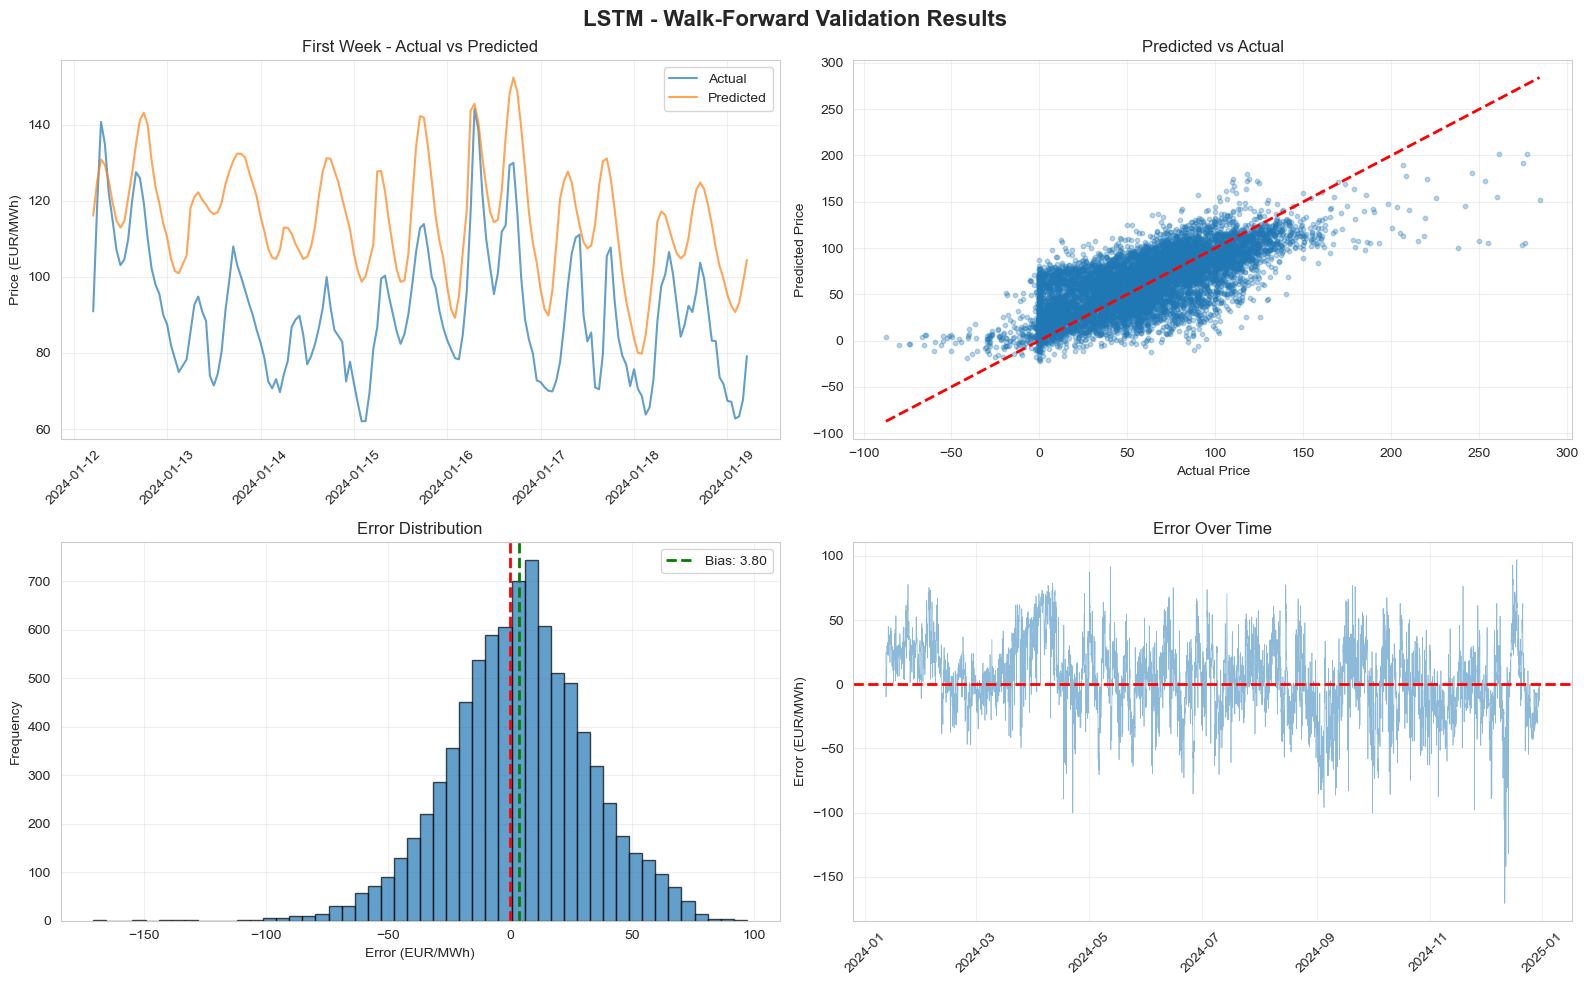

In [14]:
# Plot predictions
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('LSTM - Walk-Forward Validation Results', fontsize=16, fontweight='bold')

# 1. Time series (first week)
ax = axes[0, 0]
sample_size = min(7*24, len(predictions_df))
sample = predictions_df.head(sample_size)
ax.plot(sample['datetime_hour'], sample['actual'], label='Actual', alpha=0.7, linewidth=1.5)
ax.plot(sample['datetime_hour'], sample['predicted'], label='Predicted', alpha=0.7, linewidth=1.5)
ax.set_title('First Week - Actual vs Predicted')
ax.set_ylabel('Price (EUR/MWh)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

# 2. Scatter plot
ax = axes[0, 1]
ax.scatter(predictions_df['actual'], predictions_df['predicted'], alpha=0.3, s=10)
ax.plot([predictions_df['actual'].min(), predictions_df['actual'].max()],
        [predictions_df['actual'].min(), predictions_df['actual'].max()],
        'r--', lw=2)
ax.set_title('Predicted vs Actual')
ax.set_xlabel('Actual Price')
ax.set_ylabel('Predicted Price')
ax.grid(True, alpha=0.3)

# 3. Error distribution
ax = axes[1, 0]
ax.hist(predictions_df['error'], bins=50, alpha=0.7, edgecolor='black')
ax.axvline(0, color='red', linestyle='--', linewidth=2)
ax.axvline(predictions_df['error'].mean(), color='green', linestyle='--', linewidth=2,
           label=f"Bias: {predictions_df['error'].mean():.2f}")
ax.set_title('Error Distribution')
ax.set_xlabel('Error (EUR/MWh)')
ax.set_ylabel('Frequency')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Error over time
ax = axes[1, 1]
ax.plot(predictions_df['datetime_hour'], predictions_df['error'], alpha=0.5, linewidth=0.5)
ax.axhline(0, color='red', linestyle='--', linewidth=2)
ax.set_title('Error Over Time')
ax.set_ylabel('Error (EUR/MWh)')
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 8. Save Results

In [15]:
# Save predictions
output_dir = project_root / "research/reports"
output_dir.mkdir(parents=True, exist_ok=True)

predictions_df.to_csv(output_dir / "lstm_predictions.csv", index=False)

# Save metrics
metrics_file = output_dir / "lstm_metrics.txt"
with open(metrics_file, 'w') as f:
    f.write("LSTM - Walk-Forward Results\n")
    f.write("="*80 + "\n\n")
    for key, value in metrics.items():
        f.write(f"{key}: {value:.4f}\n")

print("\n✅ Results saved:")
print(f"   - {output_dir / 'lstm_predictions.csv'}")
print(f"   - {output_dir / 'lstm_metrics.txt'}")


✅ Results saved:
   - c:\Users\arnov\Desktop\energy-demand-forecast\research\reports\lstm_predictions.csv
   - c:\Users\arnov\Desktop\energy-demand-forecast\research\reports\lstm_metrics.txt


## 9. Summary & Comparison with Other Models

### LSTM Performance

**Strengths:**
- ✅ **Temporal learning**: Captures sequential patterns
- ✅ **Non-linear**: Complex relationships
- ✅ **No manual feature engineering**: Learns features automatically

**Limitations:**
- ⚠️ **Slow training**: 10-30 minutes per retrain
- ⚠️ **Needs more data**: Performance improves with more data
- ⚠️ **Less interpretable**: Black box
- ⚠️ **Hyperparameter sensitive**: Requires tuning

### When to Use LSTM?

**Use LSTM when:**
- Strong temporal patterns (hourly cycles, weekly patterns)
- Large dataset (>1 year of hourly data)
- Complex feature interactions
- Retraining not frequent (weekly, not daily)

**Use Tree Models (XGBoost/LightGBM) when:**
- Need fast predictions
- Daily retraining required
- Need interpretability (feature importance)
- Limited data



### Next Steps

1. **Compare all models**: Ridge, XGBoost, LightGBM Quantile, LSTM
2. **Ensemble**: Combine models (e.g., average of XGBoost + LSTM)
3. **Hyperparameter tuning**: Grid search for optimal parameters
4. **Feature engineering**: Add more relevant features
5. **Production pipeline**: Automate daily forecasting and retraining